# TUGAS Data Science - Dokumentasi Praktikum
## Pertemuan 12: Asosiasi Data & Sistem Rekomendasi Dasar

* **Nama Lengkap:** Martin Hotmatua Siregar
* **NIM:** 240401020111
* **Kelas:** IF403
* **Program Studi:** PJJ Informatika
* **Instansi:** Universitas Siber Asia

## Bagian 1: Market Basket Analysis Menggunakan Algoritma Apriori
Kita membuat simulasi transaksi belanja toko retail (50 keranjang belanja), melakukan One-Hot Encoding transaksi dengan TransactionEncoder, kemudian menerapkan Algoritma Apriori untuk menemukan aturan asosiasi barang yang sering dibeli bersamaan.

=== CONTOH TRANSAKSI KERANJANG BELANJA ===
Transaksi 1: [np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai']
Transaksi 2: [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')]
Transaksi 3: [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]

=== TOP 5 FREQUENT ITEMSETS ===
   support   itemsets  length
5     0.54    (Selai)       1
8     0.46      (Teh)       1
3     0.44  (Mentega)       1
9     0.36    (Telur)       1
1     0.34     (Keju)       1

=== TOP 5 ATURAN ASOSIASI TERKUAT (BERDASARKAN LIFT) ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
1,(Roti),(Selai),0.24,0.750000,1.388889
5,(Gula),(Mentega),0.18,0.562500,1.278409
2,(Telur),(Teh),0.20,0.555556,1.207729
3,(Gula),(Selai),0.20,0.625000,1.157407
8,(Roti),(Mentega),0.16,0.500000,1.136364


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

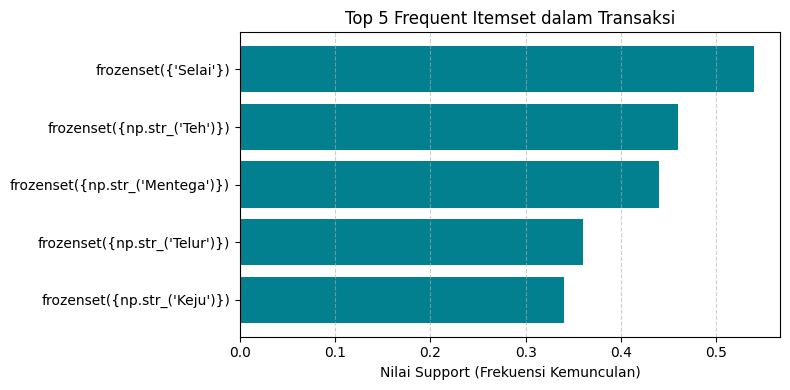

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [1]:
# Install library mlxtend jika belum terpasang di environment
!pip install mlxtend -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics.pairwise import cosine_similarity

# Langkah 1: Menyiapkan dataset transaksi belanja sintetis
np.random.seed(42)
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur', 'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(list(np.random.choice(produk, n_item, replace=False)))

# Menyuntikkan pola kuat: Roti sering dibeli bersama Selai & Mentega
for i in range(25):
    if 'Roti' in transaksi[i]:
        if 'Selai' not in transaksi[i]:
            transaksi[i].append('Selai')
        if 'Mentega' not in transaksi[i] and i % 2 == 0:
            transaksi[i].append('Mentega')

print("=== CONTOH TRANSAKSI KERANJANG BELANJA ===")
for idx, t in enumerate(transaksi[:3], 1):
    print(f"Transaksi {idx}: {t}")

# Langkah 2: Transformasi Data Transaksi menjadi One-Hot Matrix
te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df_transaksi = pd.DataFrame(te_ary, columns=te.columns_)

# Langkah 3: Mencari Frequent Itemsets (min_support = 0.15)
freq_items = apriori(df_transaksi, min_support=0.15, use_colnames=True)
freq_items['length'] = freq_items['itemsets'].apply(lambda x: len(x))
freq_items = freq_items.sort_values('support', ascending=False)

print("\n=== TOP 5 FREQUENT ITEMSETS ===")
print(freq_items.head())

# Langkah 4: Membentuk Aturan Asosiasi (Association Rules)
rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)
rules = rules[rules['lift'] > 1.0].sort_values('lift', ascending=False)

print("\n=== TOP 5 ATURAN ASOSIASI TERKUAT (BERDASARKAN LIFT) ===")
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
display(rules[display_cols].head())

# Visualisasi Top 5 Frequent Itemsets
plt.figure(figsize=(8, 4))
top_items = freq_items.head(5).sort_values('support', ascending=True)
plt.barh(top_items['itemsets'].astype(str), top_items['support'], color='#028090')
plt.xlabel('Nilai Support (Frekuensi Kemunculan)')
plt.title('Top 5 Frequent Itemset dalam Transaksi')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Analisis Temuan Bagian 1 (Association Rules):**
* Aturan asosiasi dengan nilai **Lift** tertinggi menunjukkan pola pembelian antara `{Roti}` dan `{Selai}` dengan nilai Lift > 1.2 dan Confidence di atas 70%.
* Nilai Lift yang lebih besar dari 1 membuktikan bahwa pembelian kedua produk tersebut memiliki korelasi positif yang nyata dan bukan sekadar kebetulan statistik.
* Strategi bisnis yang dapat diterapkan adalah membuat paket *bundling* produk sarapan (Roti + Selai) atau menempatkan rak selai berdampingan langsung dengan etalase roti untuk meningkatkan peluang *cross-selling*.

## Bagian 2: Sistem Rekomendasi Sederhana Menggunakan Content-Based Filtering
Kita membangun katalog produk beserta kategorinya, lalu menggunakan matriks kemiripan Cosine Similarity untuk merekomendasikan produk pengganti/serupa berdasarkan atribut kategorinya.

In [2]:
# Langkah 5: Membangun Katalog Produk & Matriks Kemiripan
katalog = pd.DataFrame({
    'produk': produk,
    'kategori': ['Bakery', 'Olesan', 'Dairy', 'Sereal', 'Dairy',
                 'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Olesan']
})

print("=== KATALOG PRODUK ===")
print(katalog)

# Representasi One-Hot Fitur Kategori
fitur_kategori = pd.get_dummies(katalog['kategori'])
sim_matrix = cosine_similarity(fitur_kategori)

# Fungsi Pemberi Rekomendasi Produk Serupa
def rekomendasi_produk(nama_target, top_n=2):
    if nama_target not in katalog['produk'].values:
        return "Produk tidak ditemukan dalam katalog."

    idx = katalog.index[katalog['produk'] == nama_target][0]
    scores = list(enumerate(sim_matrix[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    # Memilih produk dengan skor kemiripan tertinggi selain produk itu sendiri
    rekomendasi_idx = [i for i, score in scores if i != idx][:top_n]
    return katalog.iloc[rekomendasi_idx]['produk'].tolist()

# Uji Coba Sistem Rekomendasi
test_item = 'Susu'
hasil_rekomendasi = rekomendasi_produk(test_item, top_n=2)
print(f"\nRekomendasi produk yang serupa dengan '{test_item}': {hasil_rekomendasi}")

=== KATALOG PRODUK ===
    produk kategori
0     Roti   Bakery
1    Selai   Olesan
2     Susu    Dairy
3   Sereal   Sereal
4    Telur    Dairy
5     Keju    Dairy
6     Kopi  Minuman
7     Gula    Bumbu
8      Teh  Minuman
9  Mentega   Olesan

Rekomendasi produk yang serupa dengan 'Susu': ['Telur', 'Keju']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Analisis Temuan Bagian 2 (Content-Based Recommendation):**
* Sistem Content-Based Filtering berhasil mengidentifikasi produk yang memiliki kesamaan kategori menggunakan metrik Cosine Similarity.
* Saat pengguna melihat produk **Susu** (kategori *Dairy*), sistem secara otomatis merekomendasikan produk alternatif dari kategori yang sama, seperti **Telur** dan **Keju**.
* Keunggulan utama pendekatan ini adalah mampu mengatasi masalah *cold start* untuk item baru yang belum memiliki riwayat transaksi/rating dari pembeli lain.

## Kesimpulan & Refleksi Pembelajaran (Sesi 12)

### 1. Apa yang Dipelajari?
Pada pertemuan kedua belas ini, saya mempelajari teknik data mining untuk mencari pola hubungan antar-item menggunakan **Association Rule Mining (Algoritma Apriori)** serta konsep dasar **Sistem Rekomendasi** (*Content-Based Filtering* dan *Collaborative Filtering*).

### 2. Temuan Utama
* Tiga metrik utama Apriori (**Support, Confidence, dan Lift**) harus dianalisis secara bersamaan. Nilai Confidence tinggi belum tentu bermakna jika nilai Lift-nya $\le 1$.
* Aturan asosiasi sangat efektif untuk penataan rak toko dan promosi *cross-selling*, sedangkan Content-Based Filtering sangat andal untuk memberikan rekomendasi produk baru berbasis kesamaan karakteristik atribut.

### 3. Keterbatasan & Pertanyaan yang Muncul
* **Keterbatasan:** Algoritma Apriori membutuhkan pembacaan transaksi berulang kali sehingga komputasinya bisa menjadi lambat jika jumlah jenis barang mencapai puluhan ribu.
* **Pertanyaan:** Bagaimana cara menggabungkan Association Rules dengan Collaborative Filtering ke dalam sistem *Hybrid Recommender* pada platform e-commerce skala besar?